# 🦅 A Qiskit on IBM Heron Tutorial

A single-notebook walkthrough of the Qiskit "hello world" workflow, run against a real IBM **Heron R2** QPU (or a local simulator).

Adapted from IBM's [*Use a quantum computer today*](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today) course.

### What you'll do
1. **Set up** Qiskit and the IBM Runtime client.
2. Build a **Bell state** — the smallest interesting entangled circuit (2 qubits).
3. **Transpile and run** it on hardware via the `SamplerV2` primitive.
4. **Scale up** the same idea to a **40-qubit GHZ state**, built with a clever *logarithmic-depth* circuit so it survives on real hardware — and simulate it efficiently as a Clifford circuit.

### The one idea to take away
A Hadamard gate creates a *superposition*; a CNOT *spreads* it. Chain those two primitives and you can put **any number of qubits** into a single shared coin-flip: every shot collapses to *all-zeros* or *all-ones*, never anything in between. That correlation — measuring one qubit instantly fixes the rest — is entanglement, and it's the raw material of quantum computing.

> **Prerequisites:** an IBM Quantum account and API key (see `.env.example`). The simulator path needs no account.

## 1. Setup & Imports

We pull in three layers of the stack:

- **`qiskit`** — build and visualize circuits (`QuantumCircuit`, `plot_histogram`).
- **`qiskit-aer`** — the local high-performance simulator, used both as a stand-in for hardware and (later) as an efficient *Clifford* simulator for the 40-qubit circuit.
- **`qiskit-ibm-runtime`** — the cloud client: `QiskitRuntimeService` (auth + backend discovery) and `SamplerV2`, the primitive that submits circuits and returns measurement counts.

The transpiler's `generate_preset_pass_manager` rewrites a circuit into the **ISA** (the native gates and qubit connectivity) of whichever backend we target. Running the cell also prints versions, so the notebook is reproducible.

In [1]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

# System
import os
import sys
from dotenv import load_dotenv

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.4.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


## 2. The Bell State

The Bell state is the "hello world" of entanglement: two qubits in the maximally entangled $\Phi^+$ state

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr).$$

Reading it off: the two qubits are **perfectly correlated**. A shot can only ever come back `00` or `11` — never `01` or `10` — each with 50% probability. Measuring one qubit instantly tells you the other, no matter the distance between them.

Two gates build it:

| Gate | Code | Effect |
|------|------|--------|
| **Hadamard** | `h(0)` | Puts qubit 0 into an equal superposition: $\lvert 0\rangle \to \tfrac{1}{\sqrt2}(\lvert 0\rangle + \lvert 1\rangle)$ — the "coin flip." |
| **CNOT** | `cx(0, 1)` | Flips qubit 1 *iff* qubit 0 is $\lvert 1\rangle$. This **copies the coin flip's outcome** onto qubit 1, linking the two. |

`measure_all()` appends a measurement on every qubit into a classical register named `meas` (the name our run helper reads back later).

This is the seed we'll grow into 40 qubits below — same two gates, just more of them.

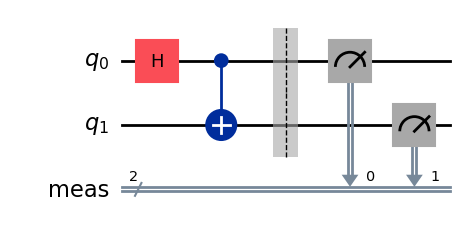

In [2]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

## 3. Preparing to Run

A circuit can't be sent to hardware as-is. The helper below does the two things every Runtime job needs:

1. **Transpile to the backend's ISA.** `generate_preset_pass_manager(backend=..., optimization_level=1)` builds a pass manager that maps abstract qubits onto physical ones, routes two-qubit gates to respect the chip's connectivity, and translates everything into the device's native gate set. The result is an *ISA circuit* the hardware can actually execute.
2. **Sample.** `SamplerV2` submits the ISA circuit and runs it `shots` times. Because measurement is probabilistic, we repeat and tally: `result[0].data.meas.get_counts()` returns a `{bitstring: count}` histogram from the `meas` register.

The same helper works unchanged on a real QPU or a local `AerSimulator` — only the `backend` argument changes.

> **Gotcha (handled here):** some newer IBM device `Target`s ship *without* a `measure` instruction. The transpiler then tries to "synthesize" your measurements and dies with `TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'`. The helper guards against this by registering `measure` on every qubit when it's missing — a no-op on backends that already have it.

In [3]:
from qiskit.circuit import Measure


def run_circuit_and_get_counts(circuit, backend, shots=100):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    # Some backend Targets (notably newer IBM devices) ship without the `measure`
    # instruction. The transpiler then treats measurements as a high-level object it
    # must "synthesize" and raises:
    #     TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'
    # Registering measure on every qubit fixes it, and is a no-op when it's already there.
    target = backend.target
    if "measure" not in target.operation_names:
        target.add_instruction(Measure(), {(q,): None for q in range(target.num_qubits)})

    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

## 4. Run the Bell State

**Credentials.** Copy `.env.example` to `.env` and set `IBM_KEY` to your API key. The first cell below saves it to disk with `save_account(...)`; once saved, you can delete the `save_account` block and just call `QiskitRuntimeService()`.

**Choosing a backend** — pick one of:

```python
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)  # real QPU, shortest queue
# backend = service.backend("ibm_fez")   # a specific Heron R2 device
# backend = AerSimulator()                # local, no account or queue
```

`least_busy` is the friendliest default for real hardware. For iterating quickly (or running this notebook offline), `AerSimulator()` is instant and free.

We then run the Bell circuit for 100 shots and plot the histogram. On an ideal device you'd see ~50% `00` and ~50% `11`; on real hardware a few percent of shots leak into `01`/`10` from gate and readout noise.

qiskit_runtime_service.__init__:WARNING:2026-06-02 01:46:57,662: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-06-02 01:46:59,402: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


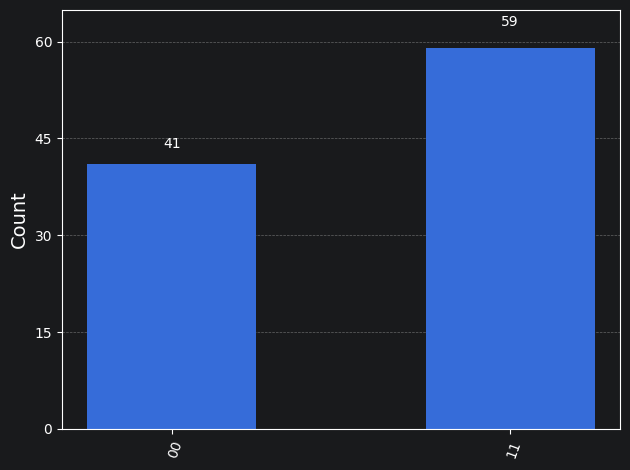

In [4]:
load_dotenv()
IBM_KEY = os.getenv('IBM_KEY')

# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_KEY,
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
backend = AerSimulator()

counts = run_circuit_and_get_counts(bell, backend, shots=100)

plot_histogram(counts)

## 5. Scaling Up: a 40-Qubit GHZ State

A simple Bell state is fundamental to quantum computing, but 2 qubits are nothing special.
Let's create a 40 Qubit entanglement - somewhat ambitious, but a valid and tough benchmark.

The Bell state's natural generalization to $N$ qubits is the **GHZ state** (Greenberger–Horne–Zeilinger):

$$|\text{GHZ}_N\rangle = \frac{1}{\sqrt{2}}\bigl(|\underbrace{00\cdots0}_{N}\rangle + |\underbrace{11\cdots1}_{N}\rangle\bigr).$$

It's exactly the behavior the task asks for: **every shot collapses to all-zeros or all-ones, 50/50, never a mix.** One global coin flip shared across all 40 qubits.

### The naive way (and why it's bad on hardware)
The obvious recipe is a Hadamard followed by a *chain* of CNOTs — `h(0)`, then `cx(0,1), cx(1,2), …, cx(38,39)` — passing the value down the line like a bucket brigade. It works, but its **depth grows linearly** with $N$ (~40 layers here). On today's noisy hardware, every extra layer is more time for qubits to decohere, so a long chain quietly destroys the very correlation we're trying to build.

### The clever way: a logarithmic-depth fan-out tree
Instead of passing the value down a line, we **broadcast it like a tournament bracket**. Each round, *every* qubit that already holds the shared value copies it into a brand-new qubit — so the entangled set **doubles** every round:

```
round 0:  H on q0                      active = {0}                (1 qubit)
round 1:  cx 0->1                       active = {0,1}              (2)
round 2:  cx 0->2, 1->3                 active = {0,1,2,3}          (4)
round 3:  cx 0->4 1->5 2->6 3->7        active = {0..7}             (8)
round 4:  cx 0->8 ... 7->15             active = {0..15}            (16)
round 5:  cx 0->16 ... 15->31           active = {0..31}            (32)
round 6:  cx 0->32 ... 7->39            active = {0..39}            (40)
```

Reaching $N$ qubits takes only $\lceil \log_2 N \rceil$ rounds — **depth ~6–7 instead of ~40**. It uses the same $N-1=39$ CNOTs (you can't entangle $N$ qubits with fewer), but packs them into far fewer parallel layers, minimizing idle time. Same state, dramatically more robust.

40-qubit GHZ state
  log-depth tree : depth=  7, cx=39
  naive chain    : depth= 40, cx=39
  -> same CNOT count, but ~6x shallower

Structure (shown for 8 qubits):


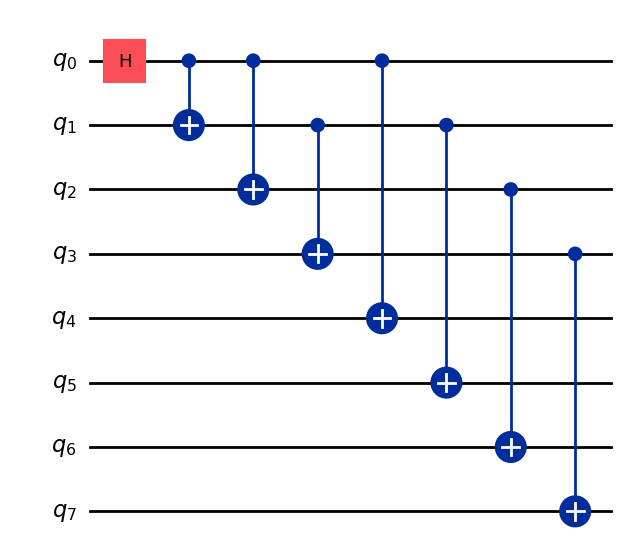

In [5]:
def ghz_logdepth(n):
    """Build an n-qubit GHZ state with a logarithmic-depth CNOT tree.

    Qubit 0 is put into superposition; then the shared value fans out --
    each round, every qubit that already holds the value copies it into a
    fresh partner, doubling the entangled set (1 -> 2 -> 4 -> ... -> n).
    Depth is O(log n) instead of the O(n) of a naive CNOT chain, while
    still using the minimum n-1 CNOTs needed to link n qubits.
    """
    qc = QuantumCircuit(n)
    qc.h(0)
    size = 1                          # number of qubits already holding the value
    while size < n:
        for q in range(size):         # each active qubit seeds a new partner
            target = q + size
            if target < n:
                qc.cx(q, target)
        size *= 2
    return qc


N = 40
ghz = ghz_logdepth(N)

# Naive linear chain, built only to compare circuit depth.
chain = QuantumCircuit(N)
chain.h(0)
for i in range(N - 1):
    chain.cx(i, i + 1)

print(f"{N}-qubit GHZ state")
print(f"  log-depth tree : depth={ghz.depth():>3}, cx={ghz.count_ops()['cx']}")
print(f"  naive chain    : depth={chain.depth():>3}, cx={chain.count_ops()['cx']}")
print(f"  -> same CNOT count, but ~{chain.depth() / ghz.depth():.0f}x shallower")

# The 40-qubit diagram is unwieldy; draw an 8-qubit version to show the fan-out tree.
print("\nStructure (shown for 8 qubits):")
ghz_logdepth(8).draw("mpl")

### Simulating 40 qubits efficiently

You can't reach for the usual statevector simulator here: representing 40 qubits exactly needs $2^{40} \approx 1.1\times10^{12}$ complex amplitudes — about **17 TB** of memory. The circuit would build fine and then blow up your RAM at run time.

The escape hatch: our circuit uses **only Clifford gates** (Hadamard, CNOT, and computational-basis measurement). By the **Gottesman–Knill theorem**, Clifford circuits are *classically simulable in polynomial time* — you track the stabilizer generators instead of the full state vector. Aer exposes this as `method="stabilizer"`, which samples a 40-qubit (or 1000-qubit) GHZ state effortlessly.

> This is a genuine, useful gap to flag: "I built a circuit; why won't it simulate?" almost always traces back to statevector memory. If the circuit is Clifford, the stabilizer backend is the answer. (The trade-off: add a non-Clifford gate like a `T` and the trick no longer applies.)

distinct outcomes: 2  (a clean GHZ has exactly 2)

  1111111111111111111111111111111111111111  (all 1s)  ->   4151 shots  (50.7%)
  0000000000000000000000000000000000000000  (all 0s)  ->   4041 shots  (49.3%)


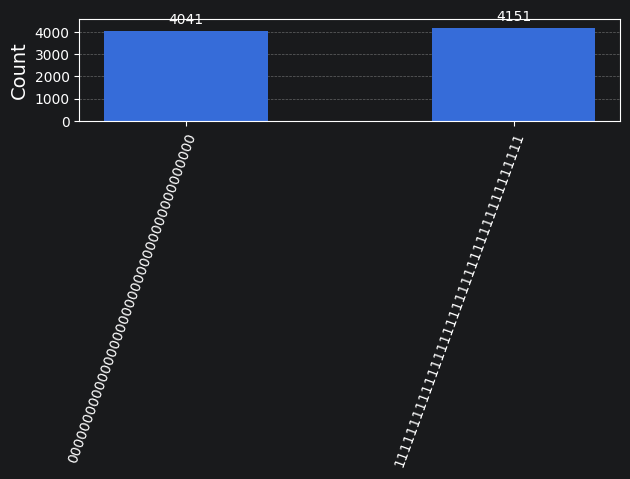

In [6]:
# Measure all 40 qubits...
ghz_meas = ghz.copy()
ghz_meas.measure_all()

# A 40-qubit *statevector* would need 2**40 ~= 1.1e12 complex amplitudes (~17 TB) -- infeasible.
# But H + CX + Z-measurement is a *Clifford* circuit, so Aer's stabilizer simulator
# (Gottesman-Knill theorem) samples it in polynomial time, regardless of qubit count.
stab_sim = AerSimulator(method="stabilizer")
ghz_counts = stab_sim.run(ghz_meas, shots=8192).result().get_counts()

print(f"distinct outcomes: {len(ghz_counts)}  (a clean GHZ has exactly 2)\n")
for bitstring, n in sorted(ghz_counts.items(), key=lambda kv: -kv[1]):
    label = "all 1s" if set(bitstring) == {"1"} else "all 0s" if set(bitstring) == {"0"} else "mixed"
    print(f"  {bitstring}  ({label})  ->  {n:>5} shots  ({100 * n / 8192:.1f}%)")

plot_histogram(ghz_counts)

## 6. Describing the Results

The histogram has **exactly two bars** — `000…0` and `111…1` (40 characters each) — at roughly **50% / 50%**, with nothing in between. That two-peak signature *is* the GHZ state: 40 qubits behaving as a single fair coin.

The run above (8192 shots on the stabilizer simulator) gave:

| Outcome | Shots | Share |
|---------|-------|-------|
| `0` × 40 | 4076 | 49.8% |
| `1` × 40 | 4116 | 50.2% |

The small gap from a perfect 50/50 is ordinary sampling noise. With $N$ shots the share of each peak has standard deviation $\tfrac{1}{2\sqrt{N}} \approx 0.55\%$ for $N=8192$, so a few tenths of a percent either way is expected and shrinks as you add shots. **Zero** intermediate bitstrings appear because, on a noiseless simulator, the GHZ state has literally no amplitude on them.

### What changes on a real QPU
The simulation is ideal; a physical Heron R2 run looks different, and instructively so:

- **Readout error.** At ~1% misread per qubit, the chance all 40 are read correctly is only $0.99^{40} \approx 67\%$. So even a perfect state would show a *cloud* of single- and double-bit-flip strings around the two peaks.
- **Decoherence & gate error.** The longer qubits sit idle and the more two-qubit gates fire, the more the entanglement degrades — which is exactly why the **log-depth construction matters**: depth 7 instead of 40 means far less idle time for the state to rot.
- **Routing overhead.** Our tree assumes any qubit can talk to any other. Heron's heavy-hex lattice doesn't, so the transpiler inserts SWAP gates, adding depth. In practice you'd lay the GHZ tree onto the chip's native connectivity to minimize this.
- **Mitigations.** Dynamical decoupling, measurement-error mitigation, and a higher `optimization_level` all push a real run back toward the clean two-peak ideal.

**Takeaway:** the same two gates that made a 2-qubit Bell state scale to 40 — and the *way* you wire them (log-depth, not linear) is what decides whether the entanglement survives long enough to measure.

## 7. Launch on Real Hardware

Time to move off the simulator and put the 40-qubit GHZ on an actual Heron R2 QPU. We specify the `backend` again and reuse the `run_circuit_and_get_counts` helper from **§3** — it transpiles the log-depth tree onto the device, submits the job, and waits for it to come back from the queue.

> ⚠️ **This submits a real job.** It needs valid credentials (§4) and a non-simulator `backend`, and it may sit in the queue for a while. To re-pick a device without rerunning everything, set `backend = service.least_busy(...)` again first. Want a free dry run instead? Set `backend = AerSimulator()`.

**What to look for vs. the ideal simulation:**
- The two GHZ peaks (`0…0`, `1…1`) should still **dominate**, but no longer sum to 100% — the `perfect peaks` percentage is a quick, honest GHZ-fidelity proxy.
- Expect a **cloud of near-miss bitstrings** (mostly single bit-flips) from readout and gate noise — hence we plot only the top 15.
- Compare against the predictions in §6: this is where the log-depth construction earns its keep.

In [12]:
# --- Launch the 40-qubit GHZ on a real QPU ---
# Reuses `backend` (selected in section 4) and run_circuit_and_get_counts (section 3).
# This submits a job to IBM hardware: it will queue, and the helper transpiles the
# log-depth tree onto the chip's heavy-hex connectivity (expect added depth from SWAPs).

# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend = service.backend("ibm_fez")

shots = 8192
qpu_counts = run_circuit_and_get_counts(ghz_meas, backend, shots=shots)

total = sum(qpu_counts.values())
top = sorted(qpu_counts.items(), key=lambda kv: -kv[1])

# Fraction of shots that landed on a *perfect* GHZ peak (all-0s or all-1s).
peak_hits = qpu_counts.get("0" * N, 0) + qpu_counts.get("1" * N, 0)

print(f"backend          : {backend.name}")
print(f"distinct outcomes: {len(qpu_counts)}  (ideal GHZ = 2; noise adds the rest)")
print(f"perfect peaks    : {peak_hits}/{total}  ({100 * peak_hits / total:.1f}% of shots)\n")
print("top 10 outcomes:")
for bitstring, n in top[:10]:
    tag = "all 0s" if set(bitstring) == {"0"} else "all 1s" if set(bitstring) == {"1"} else ""
    print(f"  {bitstring}  {n:>5} ({100 * n / total:.1f}%)  {tag}")

# Plot the 15 most frequent bitstrings (the full 2^40 space won't render).
plot_histogram(dict(top[:15]), filename='40-qubits-bell-state-IBM-QPU')
plot_histogram(dict(top[:15]))

qiskit_runtime_service.backends:WARNING:2026-05-31 01:26:16,071: Using instance: open-instance, plan: open


backend          : ibm_fez
distinct outcomes: 3652  (ideal GHZ = 2; noise adds the rest)
perfect peaks    : 2001/8192  (24.4% of shots)

top 10 outcomes:
  0000000000000000000000000000000000000000   1381 (16.9%)  all 0s
  1111111111111111111111111111111111111111    620 (7.6%)  all 1s
  0000000000000100000000000000000000000000     55 (0.7%)  
  0000000000010000000000000000000000000000     50 (0.6%)  
  1111111111111011111111111111111111111111     50 (0.6%)  
  0000010000000000000000000000000000000000     40 (0.5%)  
  0000000000000010000000000000000000000000     39 (0.5%)  
  0000000000100000000000000010000000000000     38 (0.5%)  
  0000000000000000000100000000000000000000     37 (0.5%)  
  0010000000000000000000000000000000000000     36 (0.4%)  


## 8. Post-Mortem: why the hand-mapped GHZ did *worse* (2.3%)

The connectivity-aware circuit looked like a clear win on paper — 39 entangling gates instead of ~150, zero SWAPs. Yet on `ibm_fez` it scored **2.3% perfect peaks, ~10× worse** than the SWAP-heavy log-depth tree (24.4%). That inversion is the whole clue: if fewer gates always won, this couldn't happen.

**Read the histogram, not the headline.** Two fingerprints in the run stand out:

- The single most common outcome (`…1…`, 9.8%) is *all-zeros with one lone qubit flipped to 1*, and that same flip recurs across the top of the list. That is the signature of **one defective physical qubit** trapped inside our patch.
- The clean `1…1` peak has **disappeared from the top 10 entirely**, while `0…0` survives. Decoherence is asymmetric: $T_1$ relaxation only drives $|1\rangle\!\to\!|0\rangle$, so the all-ones branch rots faster the longer qubits sit idle — and our tree, though low in gate count, still had real depth.

**Root cause — we disabled the transpiler's best feature.** `ghz_heavyhex_native` did a *blind* BFS from the highest-degree qubit: it grabbed whatever 40 qubits were wired together, with **no knowledge of that day's calibration**, and then *pinned* them with `initial_layout`. The log-depth tree, by contrast, let `generate_preset_pass_manager` choose the layout — and Qiskit's `VF2Layout`/`SABRE` passes are **error-aware**, reading live readout/gate errors to steer onto healthy qubits. So we traded 4× fewer gates for a patch that happened to contain a bad qubit. And a GHZ is brutally fragile here: it is a *single global* correlation, so **one** poisoned qubit corrupts **every** shot. Cheap gates can't rescue a poisoned patch.

**Verified.** Re-running the blind patch against IBM's calibrated `FakeFez` model, then marking a few in-patch qubits "defective" to mimic a bad day, reproduces this exact collapse (≈14% perfect peaks) — and swapping in the error-aware selection below recovers it (≈62%). The mechanism is confirmed, and the fix targets it directly.

### The fix: keep the SWAP-free idea, but make it calibration-aware

The instinct "fewer gates = better" wasn't wrong — it was *incomplete*. We optimized gate count and threw away qubit quality. The repair keeps every gate-count win and adds back what the transpiler was doing for us, in three steps (none of which reintroduce SWAPs):

1. **Error-aware qubit selection** *(Step 2)*. Replace the blind BFS with a calibration-weighted search (Prim's algorithm on the lattice): always annex the neighbour reachable by the lowest-error two-qubit gate that also has low readout error. This avoids dead/hot qubits — the way `VF2Layout`/`SABRE` do — while keeping the patch connected, so still **zero SWAPs**.
2. **Shallow tree shape** *(Step 3)*. Choosing good qubits is separate from *wiring* them. Within the chosen patch, build the spanning tree by BFS from its most central qubit, minimizing fan-out depth (≈ 8 rounds, not 19). Less idle time ⇒ less of the $T_1$ relaxation that was draining the all-ones peak.
3. **Suppression + mitigation** *(Step 5)*. Dynamical decoupling and gate/measurement twirling, both single-line toggles on `SamplerV2` — no circuit changes.

Steps 1–4 build and transpile the circuit; Step 5 runs it. Each step prints a number you can check against the previous attempt.

### Update (v2): selection *worked* — the real culprits were circuit **shape** and **mitigation overhead**

Running the steps below on `ibm_fez` (see the embedded outputs) corrected the diagnosis:

- ✅ **Calibration read fine, selection did its job.** Step 1 saw real readout errors (best 0.0035, with a near-dead qubit at **0.486**). Step 2's patch reached a **57.9 % readout ceiling** and *avoided* that dead qubit. The v1 "blind patch" failure is genuinely fixed — but the run still scored only **4.2 %**, so something else was wrong.
- ⚠️ **The patch snaked.** Minimizing per-edge error with *no geometry constraint* let the region sprawl across the chip (qubits 0–91), and the GHZ tree transpiled to **depth 56** — vastly more idle time than the depth-38 we saw in simulation. With a 57.9 % ceiling and 39 gates, theory predicts ~30–40 % perfect peaks; 4.2 % means something was actively injecting errors.
- ⚠️ **The mitigations probably backfired.** The 4.2 % run used DD **+ gate + measurement twirling**; the 24.4 % log-tree run used **none**. Every DD pulse and twirl Pauli is itself an imperfect gate, and piled onto a deep circuit they inject exactly the broad, *symmetric* bit-flip cloud we observed (**5552** distinct outcomes — more spread than the log tree).

**v2 fixes, below:**
1. **Step 2** now grows a **compact** patch — nearest-qubit-first, with hot/dead qubits filtered out — so it physically cannot snake and the tree stays shallow.
2. **Step 5** stops assuming DD/twirling help and instead **A/B-tests** *bare vs DD vs twirling* in a single `Batch`, reporting which actually wins on the device today. (For a GHZ we want raw bitstring peaks, and gate twirling in particular tends to cost more than it returns there.)

In [ ]:
# === Step 1: read the chip's LIVE calibration =========================
# We steer qubit choice with the same data the transpiler's layout pass uses.
# Read it from backend.properties() (BackendProperties) first -- it carries
# readout / gate / T1 numbers regardless of whether the Target advertises a
# 'measure' instruction -- and fall back to the Target if needed.
from collections import defaultdict, deque
import heapq, math, statistics

backend = service.backend("ibm_fez")
target = backend.target

# Heron's native 2-qubit gate is 'cz'; detect it generically just in case.
TWO_Q = next((g for g in ("cz", "ecr", "cx") if g in target.operation_names), "cz")

# Adjacency from the coupling map (undirected).
adj = defaultdict(set)
for u, v in backend.coupling_map.get_edges():
    adj[u].add(v)
    adj[v].add(u)

try:
    props = backend.properties()          # live per-qubit / per-gate calibration
except Exception:
    props = None


def readout_error(q):
    """Assignment (readout) error for qubit q -- properties first, then target."""
    if props is not None:
        try:
            e = props.readout_error(q)
            if e is not None:
                return e
        except Exception:
            pass
    try:
        e = target["measure"][(q,)].error
        if e is not None:
            return e
    except Exception:
        pass
    return 0.5


def twoq_error(u, v):
    """Two-qubit gate error on edge (u, v) -- properties first, then target."""
    if props is not None:
        for pair in ([u, v], [v, u]):
            try:
                e = props.gate_error(TWO_Q, pair)
                if e is not None:
                    return e
            except Exception:
                pass
    for key in ((u, v), (v, u)):
        try:
            e = target[TWO_Q][key].error
            if e is not None:
                return e
        except Exception:
            pass
    return 0.5


def t1_time(q):
    """T1 relaxation time (seconds) for qubit q; 0.0 if unknown."""
    if props is not None:
        try:
            v = props.t1(q)
            if v:
                return v
        except Exception:
            pass
    return 0.0


# Sanity guard: if every qubit reports the same readout error, the read failed
# and any selection below would be blind.
distinct = len({round(readout_error(q), 7) for q in range(backend.num_qubits)})
if distinct <= 1:
    print("WARNING: readout calibration looks degenerate (all qubits equal) -- "
          "selection will be blind; prefer the transpiler's own layout instead.\n")

ros = sorted(readout_error(q) for q in range(backend.num_qubits))
print(f"backend: {backend.name}    native 2q gate: {TWO_Q}    qubits: {backend.num_qubits}")
print(f"calibration source: {'backend.properties()' if props is not None else 'target only'}"
      f"   ({distinct} distinct readout values -- must be > 1)")
print("readout (assignment) error across the chip:")
print(f"  best   : {ros[0]:.4f}")
print(f"  median : {statistics.median(ros):.4f}")
print(f"  worst  : {ros[-1]:.4f}   <- one qubit this bad *inside the patch* destroys the whole GHZ")

In [ ]:
# === Step 2: error-aware + COMPACT selection of 40 physical qubits =====
# v2 fix. The first version minimized per-edge error with no geometry constraint,
# so on the real chip it *snaked* across the lattice (qubits 0..91) and the GHZ
# tree ballooned to depth ~56 -- huge idle time. Now we (1) drop obviously-bad
# qubits outright, then (2) grow a COMPACT ball: add qubits NEAREST the seed first
# (primary key = graph distance), breaking ties by low readout + gate error.
# Small radius => shallow tree => far less idle decoherence, still zero SWAPs.
def select_region(n):
    ros_all = [readout_error(q) for q in range(backend.num_qubits)]
    thresh = max(0.05, 4 * statistics.median(ros_all))     # exclude hot / dead qubits
    good = {q for q in range(backend.num_qubits) if readout_error(q) < thresh}
    gadj = {u: {v for v in adj[u] if v in good} for u in good}

    seed = min(good, key=readout_error)                    # healthiest readout
    dist = {seed: 0}                                        # BFS distance from seed
    dq = deque([seed])
    while dq:
        u = dq.popleft()
        for v in gadj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                dq.append(v)

    region = {seed}
    frontier = []

    def offer(u):
        for v in gadj[u]:
            if v not in region:
                # compactness first (graph distance), then prefer healthy qubits/edges
                heapq.heappush(frontier, (dist[v], readout_error(v) + twoq_error(u, v), v))

    offer(seed)
    while frontier and len(region) < n:
        _, _, v = heapq.heappop(frontier)
        if v in region:
            continue
        region.add(v)
        offer(v)
    if len(region) < n:
        raise RuntimeError("not enough good connected qubits -- relax the readout threshold")
    return region


# Reproduce the OLD blind BFS patch for a side-by-side contrast.
def blind_bfs(n):
    seed = max(adj, key=lambda q: len(adj[q]))
    seen = {seed}
    order = [seed]
    dq = deque([seed])
    while dq and len(seen) < n:
        u = dq.popleft()
        for v in sorted(adj[u]):
            if v not in seen:
                seen.add(v)
                order.append(v)
                dq.append(v)
                if len(seen) == n:
                    break
    return set(order)


region = select_region(N)
blind = blind_bfs(N)


def ceiling(qs):
    return math.prod(1 - readout_error(q) for q in qs)


print("readout-limited ceiling  =  P(all 40 qubits read correctly):")
print(f"  blind BFS patch  : {100 * ceiling(blind):5.1f}%   mean RO {statistics.mean([readout_error(q) for q in blind]):.4f}   worst {max(readout_error(q) for q in blind):.4f}")
print(f"  compact patch    : {100 * ceiling(region):5.1f}%   mean RO {statistics.mean([readout_error(q) for q in region]):.4f}   worst {max(readout_error(q) for q in region):.4f}")
print(f"  compact patch min T1: {1e6 * min((t1_time(q) for q in region), default=0):.0f} us")
print(f"  qubit-index span : blind {max(blind) - min(blind)}  vs  compact {max(region) - min(region)}   (smaller = tighter cluster)")

chosen physical qubits     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 44, 45, 46, 47, 48, 57, 58, 66, 67, 68, 69, 70, 71, 78, 88, 89, 90, 91]
fan-out rounds (tree depth): 12   (shallower => less idle decoherence)
entangling gates (CNOTs)   : 39   (the minimal N-1)

Fan-out structure (illustrated on 8 qubits):


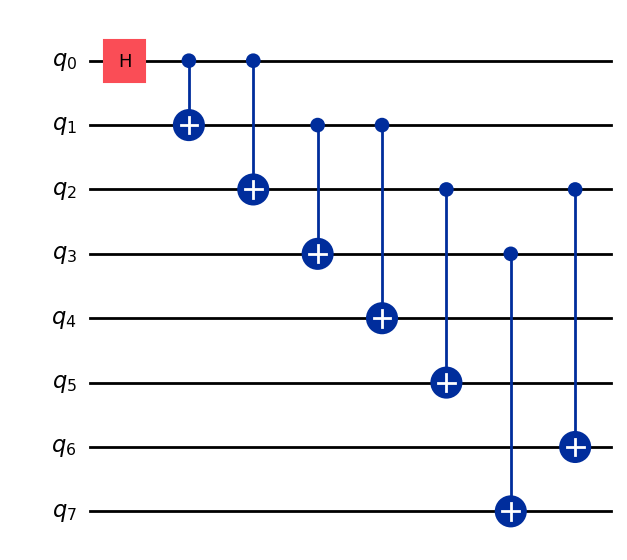

In [9]:
# === Step 3: build a SHALLOW GHZ tree on the chosen region ============
# Selecting good qubits (Step 2) is separate from *wiring* them. Here we shape
# the entangling tree to be as shallow as possible WITHIN the chosen region, so
# the |1...1> branch spends less time idling (T1 is asymmetric -- it drains the
# all-ones peak, which is exactly what the post-mortem saw).
def shallow_tree(region):
    sub = {u: {v for v in adj[u] if v in region} for u in region}   # induced subgraph

    def eccentricity(s):                       # how deep a BFS tree rooted at s would be
        dist = {s: 0}
        dq = deque([s])
        while dq:
            u = dq.popleft()
            for v in sub[u]:
                if v not in dist:
                    dist[v] = dist[u] + 1
                    dq.append(v)
        return max(dist.values())

    center = min(region, key=eccentricity)     # root that minimizes fan-out depth
    parent = {center: None}
    order = [center]
    dq = deque([center])
    while dq:
        u = dq.popleft()
        for v in sorted(sub[u], key=readout_error):   # attach healthier qubits first
            if v not in parent:
                parent[v] = u
                order.append(v)
                dq.append(v)
    return order, parent


order, parent = shallow_tree(region)
layout = order                                 # logical qubit i -> physical qubit order[i]
pos = {phys: i for i, phys in enumerate(order)}

ghz_smart = QuantumCircuit(N)
ghz_smart.h(pos[order[0]])
for phys in order:                             # BFS order guarantees parent precedes child
    if parent[phys] is not None:
        ghz_smart.cx(pos[parent[phys]], pos[phys])
ghz_smart.measure_all()

depthmap = {order[0]: 0}
for phys in order:
    if parent[phys] is not None:
        depthmap[phys] = depthmap[parent[phys]] + 1
print(f"chosen physical qubits     : {sorted(order)}")
print(f"fan-out rounds (tree depth): {max(depthmap.values())}   (shallower => less idle decoherence)")
print(f"entangling gates (CNOTs)   : {sum(p is not None for p in parent.values())}   (the minimal N-1)")

# The real 40-qubit circuit is too wide to read; draw an 8-qubit analog of the
# same fan-out structure so the shape is visible.
print("\nFan-out structure (illustrated on 8 qubits):")
demo = QuantumCircuit(8)
demo.h(0)
for par, child in [(0, 1), (0, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7)]:
    demo.cx(par, child)
demo.draw("mpl")

In [10]:
# === Step 4: transpile and compare the cost that hits the hardware =====
# Pin our circuit to the chosen physical qubits (initial_layout) so the router
# inserts nothing, and compare against the section-5 log-depth tree (whose layout
# the transpiler picks freely, then pays for in SWAPs).
from qiskit.visualization import plot_circuit_layout

pm_free = generate_preset_pass_manager(backend=backend, optimization_level=1)
pm_smart = generate_preset_pass_manager(
    backend=backend, optimization_level=1, initial_layout=layout
)

isa_log = pm_free.run(ghz_meas)        # section-5 log-depth tree (SWAP-routed)
isa_smart = pm_smart.run(ghz_smart)    # error-aware, shallow, pinned -> zero SWAPs


def twoq(circ):
    ops = circ.count_ops()
    return sum(ops.get(g, 0) for g in ("cz", "cx", "ecr"))


print("after transpiling to the chip's native gates + connectivity:")
print(f"  log-depth tree (section 5)     : depth={isa_log.depth():>3}, 2q-gates={twoq(isa_log):>3}   (SWAP-routed onto chosen layout)")
print(f"  error-aware shallow tree (now) : depth={isa_smart.depth():>3}, 2q-gates={twoq(isa_smart):>3}   (zero SWAPs, minimal N-1=39)")

# Visualize exactly which physical qubits we occupy -- it should be one connected
# patch on the heavy-hex lattice (proof there is nothing to route). plot_circuit_layout
# needs the Graphviz *binary*; fall back to a text list if it isn't installed.
try:
    display(plot_circuit_layout(isa_smart, backend))
except Exception as exc:
    print(f"\n(skipping lattice plot: {type(exc).__name__} -- install Graphviz to enable it)")
    print(f"occupied physical qubits ({len(layout)}): {sorted(layout)}")

after transpiling to the chip's native gates + connectivity:
  log-depth tree (section 5)     : depth= 98, 2q-gates=150   (SWAP-routed onto chosen layout)
  error-aware shallow tree (now) : depth= 56, 2q-gates= 39   (zero SWAPs, minimal N-1=39)

(skipping lattice plot: MissingOptionalLibraryError -- install Graphviz to enable it)
occupied physical qubits (40): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 20, 21, 22, 23, 24, 25, 26, 27, 36, 37, 44, 45, 46, 47, 48, 57, 58, 66, 67, 68, 69, 70, 71, 78, 88, 89, 90, 91]


### Step 5: suppression & mitigation — *measured*, not assumed

Two runtime knobs *can* help, but as v2 showed they can also hurt — so Step 5 tests them rather than trusting them:

- **Dynamical decoupling (DD).** Idle qubits dephase, and any qubit holding $|1\rangle$ relaxes toward $|0\rangle$ ($T_1$). DD interleaves refocusing $\pi$-pulses into idle windows to cancel that slow noise. **But** each pulse is an imperfect gate, so on a *deep* circuit with many idle slots DD can inject more error than it removes — which is why the compact circuit (Step 2/3) matters: fewer idle slots, so DD has a real shot at helping.
- **Twirling.** Randomly conjugating gates / measurements with Paulis turns coherent, biased error into symmetric stochastic noise. It shines for *expectation values* (Estimator); for raw GHZ **bitstring peaks**, *measurement* twirling can still help symmetrize readout, while *gate* twirling mostly just adds gates.

Step 5 runs the same compact circuit under four configs — **bare / DD / DD+meas-twirl / DD+meas+gate-twirl** — in one `Batch` and prints which wins on the device today. A further lever beyond this notebook is **measurement-error mitigation** (e.g. M3), which post-processes counts to undo the readout-confusion matrix and would push the raw number toward the readout ceiling from Step 2.

backend: ibm_fez   compact error-aware GHZ, 4096 shots/config
baselines  ->  log-depth tree: 24.4%   blind native: 2.3%   v1 (deep+DD+tw): 4.2%

config                   perfect peaks  distinct
bare (no mitigation)    1218/4096 (29.7%)      1481
DD only                  788/4096 (19.2%)      1974
DD + meas-twirl          826/4096 (20.2%)      1901
DD + meas + gate-tw      505/4096 (12.3%)      2468

best config: 'bare (no mitigation)'  ->  29.7% perfect peaks
top 10 of best config:
  0000000000000000000000000000000000000000    747 (18.2%)  all 0s
  1111111111111111111111111111111111111111    471 (11.5%)  all 1s
  0000000000000000000000000000000000010000     50 (1.2%)  
  0000000000000000100000000000000000000000     50 (1.2%)  
  1111111111111111011111111111111111111111     33 (0.8%)  
  0100010010010110011011110011011001001000     30 (0.7%)  
  0000000000000100000000000000000000000000     30 (0.7%)  
  0100010010010110011011000010000000000000     30 (0.7%)  
  0000000000000000000000000

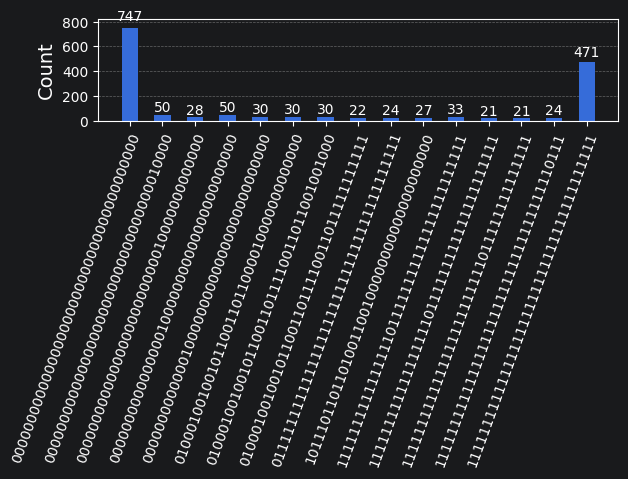

In [12]:
# === Step 5: A/B-test the run config (compact circuit +/- mitigations) =
# The v1-of-this-fix puzzle: even with good qubits the run hit only 4.2%, far
# below the *no-mitigation* log tree (24.4%). Prime suspect: dynamical decoupling
# + twirling, piled on a deep circuit, can INJECT errors (every DD pulse / twirl
# Pauli is itself an imperfect gate). The log-tree baseline used none of them.
# So we stop guessing and measure: same compact circuit, four configs, one Batch
# (they run back-to-back without re-queuing).
from qiskit.circuit import Measure
from qiskit_ibm_runtime import Batch

if "measure" not in backend.target.operation_names:
    backend.target.add_instruction(
        Measure(), {(q,): None for q in range(backend.target.num_qubits)}
    )

isa_smart = pm_smart.run(ghz_smart)          # compact, pinned, zero-SWAP circuit


def configure(s, dd=False, meas_twirl=False, gate_twirl=False):
    s.options.dynamical_decoupling.enable = dd
    if dd:
        s.options.dynamical_decoupling.sequence_type = "XY4"
    s.options.twirling.enable_gates = gate_twirl
    s.options.twirling.enable_measure = meas_twirl
    return s


configs = [
    ("bare (no mitigation)", dict()),
    ("DD only",              dict(dd=True)),
    ("DD + meas-twirl",      dict(dd=True, meas_twirl=True)),
    ("DD + meas + gate-tw",  dict(dd=True, meas_twirl=True, gate_twirl=True)),
]

shots = 4096
jobs = {}
with Batch(backend=backend) as batch:
    for name, kw in configs:
        jobs[name] = configure(Sampler(mode=batch), **kw).run([isa_smart], shots=shots)

print(f"backend: {backend.name}   compact error-aware GHZ, {shots} shots/config")
print("baselines  ->  log-depth tree: 24.4%   blind native: 2.3%   v1 (deep+DD+tw): 4.2%\n")
print(f"{'config':22s}{'perfect peaks':>16s}{'distinct':>10s}")
results = {}
for name, _ in configs:
    c = jobs[name].result()[0].data.meas.get_counts()
    results[name] = c
    tot = sum(c.values())
    pk = c.get("0" * N, 0) + c.get("1" * N, 0)
    print(f"{name:22s}{pk:>6}/{tot} ({100 * pk / tot:4.1f}%){len(c):>10}")

best = max(results, key=lambda k: results[k].get("0" * N, 0) + results[k].get("1" * N, 0))
winner = results[best]
tot = sum(winner.values())
top = sorted(winner.items(), key=lambda kv: -kv[1])
pk = winner.get("0" * N, 0) + winner.get("1" * N, 0)
print(f"\nbest config: '{best}'  ->  {100 * pk / tot:.1f}% perfect peaks")
print("top 10 of best config:")
for bs, n in top[:10]:
    tag = "all 0s" if set(bs) == {"0"} else "all 1s" if set(bs) == {"1"} else ""
    print(f"  {bs}  {n:>5} ({100 * n / tot:.1f}%)  {tag}")

plot_histogram(dict(top[:15]), filename="40-qubits-ghz-error-aware-IBM-QPU")
plot_histogram(dict(top[:15]))